# Introduction

This notebook is strucuted in two main sections (see table of content)
1) Model Development: Used to experiment on different model architectures and evaluate on test set results

2) Model Deployment: Used to train a final model on the full data set, uploade results to S3 and define all variables for model_config.py 



# Model Development

In [7]:
!pip install awswrangler
!pip install --upgrade google-api-python-client oauth2client
!pip install gspread
!pip install catboost
!pip install hvac

  Using cached hvac-0.11.2-py2.py3-none-any.whl (148 kB)


In [24]:
import sys 
import os
sys.path.append("/home/ec2-user/SageMaker/ml-demand-forecasting")

from catboost import CatBoostRegressor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import DataConversionWarning
from pandas.core.common import SettingWithCopyWarning
import warnings
import matplotlib.pyplot as plt
import pickle
import awswrangler as wr

from src.io.loaders import load_label_encoder
from src.io.loaders import upload_file_to_s3
from src.io.loaders import save_model_to_s3
from src.io.loaders import download_file_from_s3
from config.project_config import *
from config.model_config import *

from datetime import date, datetime, timedelta
from dateutil.relativedelta import relativedelta
import seaborn as sns

from src.preprocessing.offline_size_dist_deploy import resize_dist
from src.queries.query_du_strategy_dfm_offline import query_du_strategy_dfm_offline
from src.queries.week_in_month_v2 import week_in_month_v2
from src.feature.predict_du_deploy_offline import predict_du_deploy

from src.postprocessing.adjust_size_distribution_for_tops import adjust_size_distribution
from src.preprocessing.prep_sizes import change_slash_size, map_size 
from src.postprocessing.adjust_size_distribution_offline import resize_dist, get_size_dist_offline
from src.utils.function_lib import normal_round

from src.model.metrics import accuracy, bias

from sklearn.metrics import mean_squared_error, mean_absolute_error

from config.project_config import S3_BUCKET

from config.project_config import (
    SIZE_DIST_OFFLINE_FILE_NAME,
    SIZE_DIST_OFFLINE_FILE_ID,
    SIZE_DIST_OFFLINE_CAT1_FILE
)
from src.feature.feature_lib import (
    get_feature_distribution,
    get_historic_week_dist_feature,
    get_size_distribution,
    get_historic_sales_statistics,
    add_price_features
)

from src.model.training_preparation import resample_to_cluster_level, get_undersampling_index


def mean_abs_error_percent(y_true, y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    mean_demand = np.mean(y_true)
    return (mae / mean_demand) * 100

def report_model_performance(model_name: str, y_true, y_pred):
    acc = np.round(mean_abs_error_percent(y_true, y_pred))
    b = np.round(bias(y_true, y_pred),2)
    mae = np.round(mean_absolute_error(y_true, y_pred),2)
    avg_sales = np.round(np.mean(y_true),2)
    avg_pred = np.round(np.mean(y_pred),2)
    
    print(f'Percentage error of {model_name}: {acc}%')
    print(f'Bias of {model_name}: {b}')
    print(f'Mean absolute error of {model_name}: {mae}')
    print(f'Average actual sales: {avg_sales}')
    print(f'Average prediction: {avg_pred}')
    
    
# local folder to store external files. E.g. traffic data
external_data_file_path = "/home/ec2-user/SageMaker/ml-demand-forecasting/temp/external_data/"
if not os.path.exists(external_data_file_path):
    os.makedirs(external_data_file_path)

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings(action="ignore", category=DataConversionWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 10000)
pd.set_option("max_colwidth", 10000)


if not os.path.exists(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}'):
    os.makedirs(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}')

# Columns used for analysis but not for training
# need to add date_released to master_join and NO_TRAIN_COLS
NO_TRAIN_COLS = ['release_collection_name', 'id_product', 'id_product_attribute']

In [21]:
READ_COLS =  FEATURES_OFFLINE + NO_TRAIN_COLS + ['adjusted_net_units_sold']
master_join = pd.read_parquet(S3_OFFLINE_DATA_FILE_PATH)

master_join = master_join[master_join.cluster != '-']
master_join.week_id = master_join.week_id.str.replace('week','').astype(int)
master_join['first_available_year'] = master_join['first_available_date'].dt.year

In [22]:
''' Creating test set '''
NUM_TEST_SET_COLLECTIONS = int(master_join.release_collection_name.nunique() * 0.15)

master_join.sort_values(by = 'first_available_date', inplace = True)
master_join = master_join[~master_join.cluster.isna()]

temp = master_join.groupby('release_collection_name')['first_available_date'].min().reset_index()
temp.sort_values(by = 'first_available_date', inplace = True)
test_set_collections = temp['release_collection_name'][-NUM_TEST_SET_COLLECTIONS:]

data_test = master_join[master_join.release_collection_name.isin(test_set_collections)]

print(f'Min test set date: {data_test.first_available_date.min()}')
print(f'Max test set date: {data_test.first_available_date.max()}')

data_train = master_join[~master_join.release_collection_name.isin(test_set_collections)]
# Clean remaining dates in 2022
data_train = data_train[data_train.first_available_year != 2022]
data_train = data_train[data_train.first_available_year > 2019]


collection_percentage = data_test.release_collection_name.nunique() / (data_train.release_collection_name.nunique() + data_test.release_collection_name.nunique())
print(f'Percentage of collections in test set: {np.round(collection_percentage * 100,2)}')

product_percentage = data_test.id_product.nunique() / (data_train.id_product.nunique() + data_test.id_product.nunique())
print(f'Percentage of products in test set: {np.round(product_percentage* 100,2)}')

Min test set date: 2021-11-23 00:00:00
Max test set date: 2022-05-31 00:00:00
Percentage of collections in test set: 19.54
Percentage of products in test set: 15.24


### Feature Engineering

In [25]:
feature_dist = get_feature_distribution(data_train)

In [26]:
#data_train = resample_to_cluster_level(data_train)
#data_train.to_csv('./data_train_resampled.csv')
data_train = pd.read_csv('./data_train_resampled.csv', index_col=0)

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/IPython/core/interactiveshell.py:3072: DtypeWarning: Columns (17,18,19,20,21,22,23) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [27]:
''' Create and add features  '''

data_train = add_price_features(data_train)

feature_sales_category, feature_sales_category2, feature_sales_cluster = get_historic_sales_statistics(data_train)

week_dist = get_historic_week_dist_feature(data_train)
week_dist.drop(columns = ["adjusted_net_units_sold", "total_sales"], axis = 1, inplace = True)

size_dist_features = get_size_distribution(data_train, 'adjusted_net_units_sold')
size_dist_features.rename(columns = {'size_dist': 'feature_size_dist'},inplace = True)


# Add discount, traffic and retail_dist features
data_train = pd.merge(
    data_train,
    feature_dist,
    on = ["id_shop_name",'sub_product_line','henry_category_2', "cluster", "week_id"],
    how = 'left'
)

# Sales by category
data_train = pd.merge(
    data_train,
    feature_sales_category,
    on = ['henry_category_2', 'size', 'color','week_id'],
    how = 'left'
)

# Sales by category2
data_train = pd.merge(
    data_train,
    feature_sales_category2,
    on = ['henry_category_2', 'size', 'color', 'cluster' ,'week_id'],
    how = 'left'
)

# Sales by cluster
data_train = pd.merge(
    data_train,
    feature_sales_cluster,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'size','week_id'],
    how = 'left'
)

# Size distribution
data_train = pd.merge(
    data_train,
    size_dist_features,
    on = ['id_shop_name', 'cluster', 'sub_product_line', 'size'],
    how = 'left'
)

# Week distribution
data_train = pd.merge(
    data_train,
    week_dist,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'id_shop_name', 'week_id'],
    how = 'left'
)

# Number of styles per collection feature
data_train['styles_in_collection'] = data_train.release_collection_name.map(
    dict(data_train.groupby('release_collection_name').id_product.nunique())
)

In [28]:
feature_cols = [col for col in data_train.columns if col.startswith('feature_')]
feature_cols

['feature_price_cannibalization',
 'feature_item_discount_mean',
 'feature_item_discount_max',
 'feature_item_discount_std',
 'feature_voucher_discount_mean',
 'feature_voucher_discount_max',
 'feature_voucher_discount_std',
 'feature_discount_utilization_mean',
 'feature_discount_utilization_max',
 'feature_discount_utilization_std',
 'feature_traffic_dist_mean',
 'feature_traffic_dist_max',
 'feature_traffic_dist_std',
 'feature_retail_mkt_spend_dist_mean',
 'feature_retail_mkt_spend_dist_max',
 'feature_retail_mkt_spend_dist_std',
 'feature_sales_cat_mean',
 'feature_sales_cat_max',
 'feature_sales_cat_std',
 'feature_sales_cat2_mean',
 'feature_sales_cat2_max',
 'feature_sales_cat2_std',
 'feature_sales_cluster_mean',
 'feature_sales_cluster_max',
 'feature_sales_cluster_std',
 'feature_size_dist']

In [29]:
""" Undersample zero sales """

# Check that we did not miss any categories
n_cat1_before = data_train.henry_category_1.nunique()
n_cat2_before = data_train.henry_category_2.nunique()
n_cat3_before = data_train.henry_category_3.nunique()
n_cluster_before = data_train.cluster.nunique()
n_product_line_before = data_train.product_line.nunique()
n_spl_before = data_train.sub_product_line.nunique()
n_color_before = data_train.color.nunique()
n_simple_color_before = data_train.simple_color.nunique()
n_id_shop_before = data_train.id_shop_name.nunique()
n_size_before = data_train["size"].nunique()


new_idx = get_undersampling_index(data_train.adjusted_net_units_sold)
data_train = data_train[data_train.index.isin(new_idx)]
print(f'Proportion of zero sales in train data: {len(data_train[data_train.adjusted_net_units_sold == 0]) / len(data_train)}')


assert n_cat1_before == data_train.henry_category_1.nunique()
assert n_cat2_before == data_train.henry_category_2.nunique()
assert n_cat3_before == data_train.henry_category_3.nunique()
assert n_cluster_before == data_train.cluster.nunique()
assert n_product_line_before == data_train.product_line.nunique()
assert n_spl_before == data_train.sub_product_line.nunique()
assert n_color_before == data_train.color.nunique()
assert n_simple_color_before == data_train.simple_color.nunique()
assert n_id_shop_before == data_train.id_shop_name.nunique()
assert n_size_before == data_train["size"].nunique()

Proportion of zero sales in train data: 0.5


In [30]:
data_train.shape[0]

456474

In [31]:
data_train.groupby("cluster").count()

,id_product,id_product_attribute,product_cost_usd,original_price_usd,size,product_line,sub_product_line,henry_category_1,henry_category_2,henry_category_3,simple_color,color,fabric_custom_name,hscode_id_fabric_name,giveaway,pattern,sleevestyle,neckline,shape,rise,sleeve,style,release_collection_name,week_id,id_shop_name,date_released,adjusted_net_units_sold,first_available_month,first_available_dow,first_available_year,first_week_of_month,last_week_of_month,is_mega_campaign_order,avg_price_per_category,price_ratio_category,feature_price_cannibalization,feature_item_discount_mean,feature_item_discount_max,feature_item_discount_std,feature_voucher_discount_mean,feature_voucher_discount_max,feature_voucher_discount_std,feature_discount_utilization_mean,feature_discount_utilization_max,feature_discount_utilization_std,feature_traffic_dist_mean,feature_traffic_dist_max,feature_traffic_dist_std,feature_retail_mkt_spend_dist_mean,feature_retail_mkt_spend_dist_max,feature_retail_mkt_spend_dist_std,feature_sales_cat_mean,feature_sales_cat_max,feature_sales_cat_std,feature_sales_cat2_mean,feature_sales_cat2_max,feature_sales_cat2_std,feature_sales_cluster_mean,feature_sales_cluster_max,feature_sales_cluster_std,feature_size_dist,week_dist,styles_in_collection
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A,114002,114002,114002,114002,114002,114002,114002,114002,114002,23374,114002,114002,114002,114002,114002,41071,34213,60511,14874,20701,66724,81362,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,114002,113998,114002,114002,113998,114002,114002,113998,114002,114002,113998,114002,114002,113998,114002,114002,113669,114002,114002,109825,114002,114002,113703,101805,113395,114002
B,155463,155463,155463,155463,155463,155463,155463,155463,155463,27991,155463,155463,155463,155463,155463,60953,50116,85348,17994,25438,94427,111064,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155463,155450,155463,155463,155450,155463,155463,155450,155463,155463,155450,155463,155463,155450,155463,155463,155233,155463,155463,153561,155463,155463,155280,143760,155034,155463
C,135057,135057,135057,135057,135057,135057,135057,135057,135057,19003,135057,135057,135057,135057,135057,51608,45209,73851,12163,18084,82199,91966,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135057,135052,135057,135057,135052,135057,135057,135052,135057,135057,135052,135057,135057,135052,135057,135057,134770,135057,135057,132668,135057,135057,134891,130536,134532,135057
D,51952,51952,51952,51952,51952,51952,51952,51952,51952,7298,51952,51952,51952,51952,51952,18734,15347,26156,4795,6885,28895,33099,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51952,51948,51952,51952,51948,51952,51952,51948,51952,51952,51948,51952,51952,51948,51952,51952,51933,51952,51952,49111,51952,51952,51660,49906,51667,51952


In [32]:
from catboost import CatBoostRegressor
CATEGORICAL_FEATURES = [
    'size',
    'product_line',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'cluster',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'id_shop_name',
    'first_week_of_month',
    'last_week_of_month',
    'giveaway'
]

no_train_cols = [
    'id_product', 'id_product_attribute', 'release_collection_name' ,'date_released',
    'first_available_dow','first_available_month', 'first_available_year'
]

X = data_train.drop(["adjusted_net_units_sold"] + no_train_cols , axis=1)
y = data_train["adjusted_net_units_sold"]

FEATURES = X.columns
cat_idx = [key for key, val in enumerate(FEATURES) if val in set(CATEGORICAL_FEATURES)]

In [33]:
for col in CATEGORICAL_FEATURES:
    X[col].fillna('others', inplace = True)
    
for feat in feature_cols:
    X[feat].fillna(np.mean(X[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = week_dist.groupby("week_id").week_dist.mean()
for week_ in X.week_id.unique():
    X.loc[(X.week_id == week_) & (X.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]

In [34]:
split_ratio = 0.2
x_train, x_val, y_train, y_val = train_test_split(
    X, y, test_size=split_ratio, random_state=0
)

del X,y

In [35]:
clf = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=1.5,
    learning_rate=0.3,
    loss_function='RMSE'
)

clf.fit(x_train.values, y_train.values, 
        cat_features=cat_idx,
        eval_set=(x_val.values, y_val.values),
        early_stopping_rounds = 5,
        use_best_model = True,
        verbose=True,
        plot = True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7504869	test: 0.7470757	best: 0.7470757 (0)	total: 369ms	remaining: 6m 8s
1:	learn: 0.7111727	test: 0.7113512	best: 0.7113512 (1)	total: 677ms	remaining: 5m 37s
2:	learn: 0.6874302	test: 0.6900440	best: 0.6900440 (2)	total: 964ms	remaining: 5m 20s
3:	learn: 0.6727437	test: 0.6750746	best: 0.6750746 (3)	total: 1.27s	remaining: 5m 16s
4:	learn: 0.6625668	test: 0.6665810	best: 0.6665810 (4)	total: 1.54s	remaining: 5m 5s
5:	learn: 0.6552861	test: 0.6591633	best: 0.6591633 (5)	total: 1.82s	remaining: 5m 1s
6:	learn: 0.6474289	test: 0.6518080	best: 0.6518080 (6)	total: 2.09s	remaining: 4m 56s
7:	learn: 0.6433607	test: 0.6474557	best: 0.6474557 (7)	total: 2.36s	remaining: 4m 52s
8:	learn: 0.6402915	test: 0.6442111	best: 0.6442111 (8)	total: 2.64s	remaining: 4m 50s
9:	learn: 0.6367300	test: 0.6418389	best: 0.6418389 (9)	total: 2.89s	remaining: 4m 46s
10:	learn: 0.6330266	test: 0.6384157	best: 0.6384157 (10)	total: 3.14s	remaining: 4m 42s
11:	learn: 0.6286525	test: 0.6341233	best: 0

### Model Evaluation

In [36]:
report_model_performance('Validation data', y_val, clf.predict(x_val))

Percentage error of Validation data: 67.0%
Bias of Validation data: -0.0
Mean absolute error of Validation data: 0.33
Average actual sales: 0.49
Average prediction: 0.49


In [37]:
clf.save_model('./catboost_model_train')

In [ ]:
''' Load Model '''
#from_file = CatBoostRegressor()
#clf = from_file.load_model('./catboost_model_train')

Text(0.5, 1.0, 'Feature Importance')

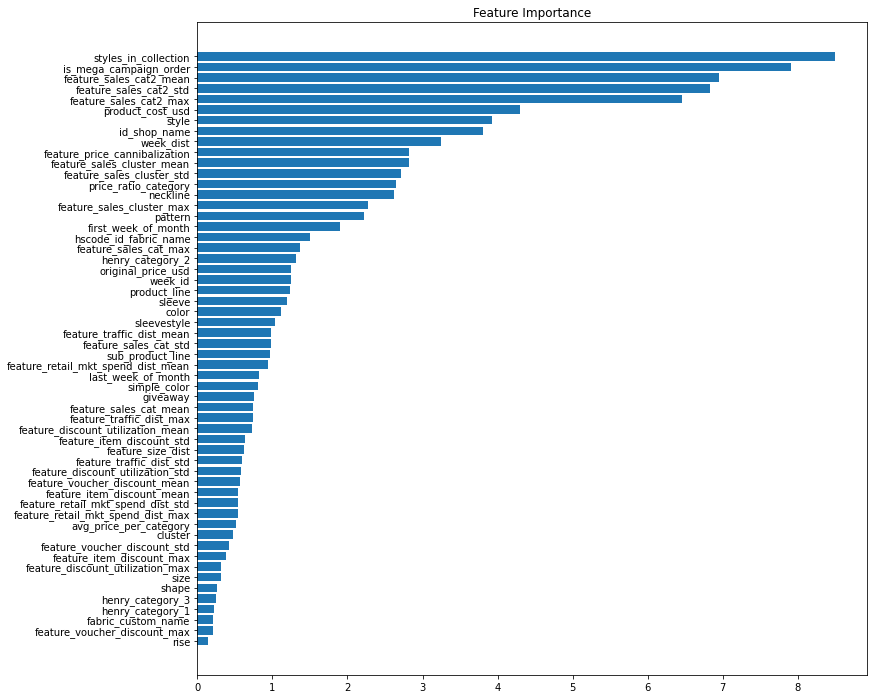

In [38]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(12, 12))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_val.columns)[sorted_idx])
plt.title('Feature Importance')

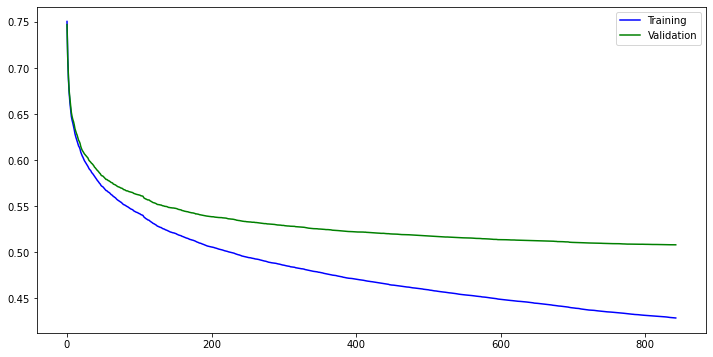

In [39]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12,6))

train_rmse = clf.evals_result_['learn']['RMSE']
val_rmse = clf.evals_result_['validation']['RMSE']
plt.plot(np.arange(0,len(train_rmse)), train_rmse, color = 'blue', label = 'Training')
plt.plot(np.arange(0,len(train_rmse)), val_rmse, color = 'green' ,label = 'Validation')
plt.legend()

In [40]:
data_test = master_join[master_join.release_collection_name.isin(test_set_collections)]

In [42]:
data_test = resample_to_cluster_level(data_test)

In [43]:
data_test.release_collection_name.nunique()

93

In [44]:
data_test.id_product.nunique()

1398

In [45]:
''' Add features to test set  '''

data_test = add_price_features(data_test)

data_test['styles_in_collection'] = data_test.release_collection_name.map(
    dict(data_test.groupby('release_collection_name').id_product.nunique())
)

# Add discount, traffic and retail_dist features
data_test = pd.merge(
    data_test,
    feature_dist,
    on = ["id_shop_name",'sub_product_line','henry_category_2', "cluster", "week_id"],
    how = 'left'
)

# Sales by category
data_test = pd.merge(
    data_test,
    feature_sales_category,
    on = ['henry_category_2', 'size', 'color','week_id'],
    how = 'left'
)

# Sales by category2
data_test = pd.merge(
    data_test,
    feature_sales_category2,
    on = ['henry_category_2', 'size', 'color', 'cluster' ,'week_id'],
    how = 'left'
)

# Sales by cluster
data_test = pd.merge(
    data_test,
    feature_sales_cluster,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'size','week_id'],
    how = 'left'
)

# Size distribution
data_test = pd.merge(
    data_test,
    size_dist_features,
    on = ['id_shop_name', 'cluster', 'sub_product_line', 'size'],
    how = 'left'
)

# Week distribution
data_test = pd.merge(
    data_test,
    week_dist,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'id_shop_name', 'week_id'],
    how = 'left'
)


In [46]:
''' Add size range '''
# To get unique size ranges first we need to order the size values and tranform them to strings
size_vals = [
    'XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL',
    'XXSXS', 'XSS', 'SM', 'ML','LXL', 'XLXXL', 
    '25', '26','27', '28', '30', '32', '34', 
    'O'
]
#assert len(size_vals) == data_test['size'].nunique()

data_test['size'] = pd.Categorical(
    data_test['size'], 
    categories=size_vals,
    ordered=True)

# sort by size to get order
data_test.sort_values(by = 'size', ascending = True, inplace = True)

# Transform back to str so we can apply .unique()
data_test[['size']] = data_test[['size']].astype(str)

size_ranges = data_test.groupby('id_product')['size'].unique().reset_index()

size_ranges['size'] = size_ranges['size'].apply(lambda x: str(x))
data_test['size_range'] = data_test['id_product'].map(dict(size_ranges.values))
print(data_test['size_range'].unique())

''' Change to old sizing '''
# Get a list of all size ranges that contain XXS
XXS_size_ranges = list()
for el in data_test.size_range.unique():
    sr = el.find('XXS')
    if sr != -1:
        XXS_size_ranges.append(el)
print(f'XXS size ranges: {XXS_size_ranges}')

# Adjust new to old sizes'''
#launched_new_sizes = (data_test.first_available_year >= 2022)

has_new_sizes = (
    data_test['size_range'].isin(XXS_size_ranges)
)

new_to_old_size_dict = {
    'XXS' : 'XS',
    'XS' : 'S',
    'S': 'M',
    'M': 'L',
    'L': 'XL',
    'XL': 'XXL',
    'XXSXS': 'XSS',
    'SM': 'ML',
    'LXL': 'XLXXL'
}

#data_test.loc[launched_new_sizes, 'size'] = data_test['size'].map(new_to_old_size_dict)

data_test.loc[data_test['size_range'].isin(XXS_size_ranges), 'old_size'] = data_test['size'].map(new_to_old_size_dict)
data_test.loc[data_test.old_size.isna(), 'old_size'] = data_test['size']

data_test.drop(columns = 'size', axis = 1, inplace = True)
data_test.rename(columns = {'old_size':'size'}, inplace = True)

["['XXS' 'XS' 'S' 'M' 'L' 'XL']" "['XXS' 'XS' 'S' 'M' 'L']"
 "['XXS' 'S' 'M']" "['XXS' 'S' 'M' 'L' 'XL']" "['XXS' 'XS' 'S' 'M']"
 "['XXS' 'XS' 'S' 'M' 'XL']" "['XS' 'S' 'M' 'L' 'XL' 'XXL']"
 "['XS' 'S' 'M' 'L']" "['XS' 'S' 'M' 'L' 'XL']" "['S' 'M' 'L' 'XL']"
 "['XXSXS' 'SM' 'LXL']" "['XSS' 'ML' 'XLXXL']"
 "['25' '26' '27' '28' '30' '32' '34']"]
XXS size ranges: ["['XXS' 'XS' 'S' 'M' 'L' 'XL']", "['XXS' 'XS' 'S' 'M' 'L']", "['XXS' 'S' 'M']", "['XXS' 'S' 'M' 'L' 'XL']", "['XXS' 'XS' 'S' 'M']", "['XXS' 'XS' 'S' 'M' 'XL']", "['XXSXS' 'SM' 'LXL']"]


In [47]:
X_pred = data_test[FEATURES]
X_pred = X_pred.reindex(columns = x_train.columns)

for col in CATEGORICAL_FEATURES:
    X_pred[col].fillna('others', inplace = True)
    
for feat in feature_cols:
    X_pred[feat].fillna(np.mean(X_pred[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = week_dist.groupby("week_id").week_dist.mean()
for week_ in X_pred.week_id.unique():
    X_pred.loc[(X_pred.week_id == week_) & (X_pred.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]

In [48]:
assert X_pred.isna().sum().sum() == 0

In [49]:
data_test['pred'] = clf.predict(X_pred.values)
data_test['pred_round'] = np.round(data_test.pred,1)
data_test['pred_round'] = np.where(data_test['pred_round'] < 0, 0, data_test['pred_round'])

In [50]:
old_to_new_size_dict = {v: k for k, v in new_to_old_size_dict.items()}

has_new_sizes = (
    data_test['size_range'].isin(XXS_size_ranges)
)

data_test.loc[data_test['size_range'].isin(XXS_size_ranges), 'new_size'] = data_test['size'].map(old_to_new_size_dict)
data_test.loc[data_test['new_size'].isna(), 'new_size'] = data_test['size']

data_test.drop(columns = 'size', axis = 1, inplace = True)
data_test.rename(columns = {'new_size':'size'}, inplace = True)
data_test['size'].unique()

array(['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL', 'XXSXS', 'XSS', 'SM',
       'ML', 'LXL', 'XLXXL', '25', '26', '27', '28', '30', '32', '34'],
      dtype=object)

In [51]:
data_test[['adjusted_net_units_sold', 'pred_round']].sample(10)

,adjusted_net_units_sold,pred_round
342644,0.833333,0.5
112377,6.000000,1.0
301349,0.000000,0.0
185442,0.000000,0.2
305905,1.500000,0.4
303617,0.000000,0.3
184632,0.250000,0.5
270279,0.600000,0.3
322841,0.000000,0.4
7484,0.000000,0.4


In [53]:
data_test

,id_product,id_product_attribute,product_cost_usd,original_price_usd,product_line,sub_product_line,henry_category_1,henry_category_2,henry_category_3,simple_color,color,fabric_custom_name,hscode_id_fabric_name,giveaway,cluster,pattern,sleevestyle,neckline,shape,rise,sleeve,style,release_collection_name,week_id,id_shop_name,date_released,adjusted_net_units_sold,first_available_month,first_available_dow,first_available_year,first_week_of_month,last_week_of_month,is_mega_campaign_order,avg_price_per_category,price_ratio_category,feature_price_cannibalization,styles_in_collection,feature_item_discount_mean,feature_item_discount_max,feature_item_discount_std,feature_voucher_discount_mean,feature_voucher_discount_max,feature_voucher_discount_std,feature_discount_utilization_mean,feature_discount_utilization_max,feature_discount_utilization_std,feature_traffic_dist_mean,feature_traffic_dist_max,feature_traffic_dist_std,feature_retail_mkt_spend_dist_mean,feature_retail_mkt_spend_dist_max,feature_retail_mkt_spend_dist_std,feature_sales_cat_mean,feature_sales_cat_max,feature_sales_cat_std,feature_sales_cat2_mean,feature_sales_cat2_max,feature_sales_cat2_std,feature_sales_cluster_mean,feature_sales_cluster_max,feature_sales_cluster_std,feature_size_dist,week_dist,size_range,pred,pred_round,size
223753,66446,205699,8.580000,19.97142,core_products,weekend,tops,blouses,NaN,yellow,yellow,woven,viscose,0,C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Feb22 : Weekend [Apr style] drop 1,6,SG,2022-02-18,0.000000,february,monday,2022,0,0,0,21.648555,0.922529,1.000000,27,0.003350,0.50,0.033689,0.005512,0.527778,0.034366,0.030870,0.625000,0.099676,5.006935,18.345365,4.059227,0.303935,1.019321,0.224743,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.118550,['XXS' 'XS' 'S' 'M' 'L' 'XL'],0.585984,0.6,XXS
145167,64207,199343,3.647234,8.54285,essential,basic,tops,tanks,NaN,purple,lilac,knit,cotton,0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Feb22: Essential,5,SG,2022-02-09,1.000000,february,saturday,2022,1,0,0,14.752364,0.579083,0.670456,17,0.001478,0.25,0.018479,0.021812,0.627273,0.080725,0.043102,0.954545,0.132420,7.965745,22.859815,4.303942,0.543080,2.665682,0.668222,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.125257,['XXS' 'XS' 'S' 'M' 'L' 'XL'],0.605281,0.6,XXS
145166,64207,199343,3.647234,8.54285,essential,basic,tops,tanks,NaN,purple,lilac,knit,cotton,0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Feb22: Essential,4,TH,2022-02-09,1.666667,february,monday,2022,1,0,0,14.752364,0.579083,0.670456,17,0.002665,0.25,0.020878,0.030767,1.000000,0.129281,0.058167,1.000000,0.159527,7.657056,24.299879,6.240838,0.367843,1.616992,0.399133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.159359,['XXS' 'XS' 'S' 'M' 'L' 'XL'],0.521840,0.5,XXS
145165,64207,199343,3.647234,8.54285,essential,basic,tops,tanks,NaN,purple,lilac,knit,cotton,0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Feb22: Essential,4,SG,2022-02-09,0.000000,february,saturday,2022,1,0,0,14.752364,0.579083,0.670456,17,0.002972,0.25,0.024554,0.010861,0.666749,0.051816,0.039552,1.000000,0.112317,7.951950,22.859815,5.384463,0.657023,2.665682,0.759913,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129363,['XXS' 'XS' 'S' 'M' 'L' 'XL'],0.483630,0.5,XXS
145164,64207,199343,3.647234,8.54285,essential,basic,tops,tanks,NaN,purple,lilac,knit,cotton,0,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Feb22: Essential,3,TH,2022-02-09,0.666667,february,monday,2022,1,0,0,14.752364,0.579083,0.670456,17,0.000000,0.00,0.000000,0.026616,1.000000,0.093709,0.041365,1.000000,0.128143,7.801420,23.143366,5.933347,0.294366,0.910170,0.261071,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.149885,['XXS' 'XS' 'S' 'M' 'L' 'XL'],0.568159,0.6,XXS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128270,63078,196746,11.010000,28.54285,core_products,workwear,bottoms,pants,straight_leg,grey,dark_grey,woven,polyester,0,B,

In [57]:
mj_agg = data_test.groupby(
    ['id_product', 'color', 'size','cluster','id_shop_name',"week_id"]
)["adjusted_net_units_sold",'pred_round'].sum().reset_index()
mj_agg
#mj_agg = mj_agg[mj_agg.adjusted_net_units_sold < mj_agg.adjusted_net_units_sold.quantile(.95)]

avg_sales_by_cluster = mj_agg.groupby(['cluster'])["adjusted_net_units_sold",'pred_round'].mean().reset_index()
avg_sales_by_cluster

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/ipykernel/__main__.py:3: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  app.launch_new_instance()
/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/ipykernel/__main__.py:7: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.


,cluster,adjusted_net_units_sold,pred_round
0,A,0.569116,0.558119
1,B,0.418913,0.465190
2,C,0.347947,0.388843
3,D,0.264752,0.330184


In [52]:
report_model_performance('catboost model', data_test.adjusted_net_units_sold, data_test.pred_round)

Percentage error of catboost model: 121.0%
Bias of catboost model: 0.04
Mean absolute error of catboost model: 0.49
Average actual sales: 0.4
Average prediction: 0.44


In [ ]:
data_test.groupbt

In [30]:
mid_list = data_test.copy()

Text(0.5, 1.0, 'Average percentage erros on test set')

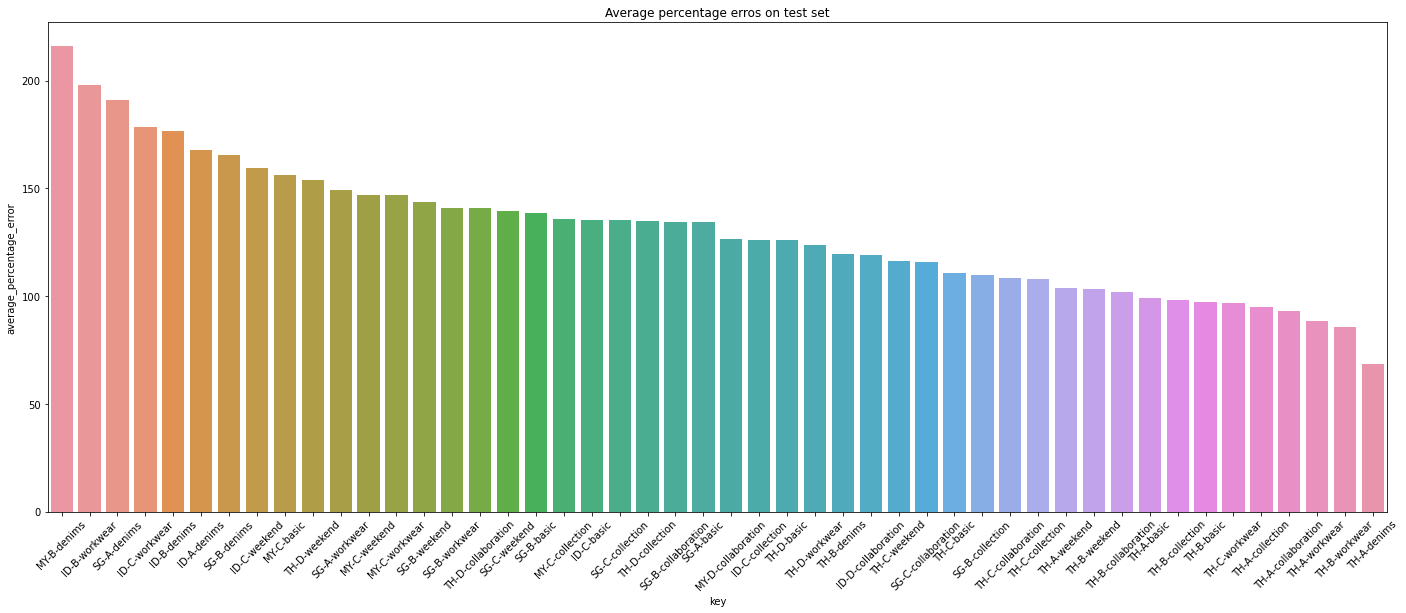

In [31]:
def mean_percentage_error(y_true, y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    mean_demand = np.mean(y_true)
    acc = (mae / mean_demand) * 100
    return acc 

#mid_list.groupby(['cluster','id_shop_name','sub_product_line']).adjusted_net_units_sold.apply(mean_percentage_error, 'pred_round')
errors = mid_list.groupby(
    ['cluster','id_shop_name','sub_product_line']
).apply(lambda x: mean_percentage_error(x['adjusted_net_units_sold'], x['pred_round'])).reset_index()
errors.rename(columns = {0 : 'average_percentage_error'}, inplace = True)
errors.sort_values(by = 'average_percentage_error', ascending = False, inplace = True)
errors['key'] = errors['id_shop_name'] + '-' + errors['cluster'] + '-' + errors['sub_product_line']

#errors.to_csv('./first_ros_errors.csv')

fig, ax = plt.subplots(figsize = (24,9))

sns.barplot(data = errors, x = 'key', y= 'average_percentage_error')
plt.xticks(rotation = 45)
plt.title('Average percentage erros on test set')

In [32]:
mid_list['week_id'] = 'week' + mid_list['week_id'].astype(str)

week_dist
week_id model                
1       prediction   0.193483
        train_data   0.237548
2       prediction   0.168346
        train_data   0.206451
3       prediction   0.154768
        train_data   0.160870
4       prediction   0.135892
        train_data   0.133396
5       prediction   0.126139
        train_data   0.102308
6       prediction   0.117889
        train_data   0.088105
7       prediction   0.103483
        train_data   0.071322

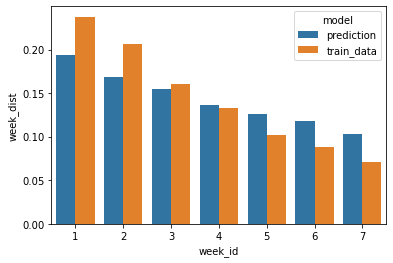

In [33]:
def get_historic_week_dist(input_df: pd.DataFrame, sales_column) -> pd.DataFrame:
    """ Returns dataframe that carries week distirbution by cat1, cluster, spl and country """
    
    total_week_sales = input_df.groupby(['henry_category_1', 'sub_product_line', 'cluster', 'id_shop_name'])[sales_column].sum().reset_index()
    total_week_sales.rename(columns = {sales_column: 'total_sales'}, inplace = True)

    week_dist_data = input_df.groupby(['henry_category_1', 'sub_product_line', 'cluster', 'id_shop_name', 'week_id'])[sales_column].sum().reset_index()
    week_dist_data = pd.merge(
        week_dist_data,
        total_week_sales,
        on = ['henry_category_1', 'sub_product_line', 'cluster', 'id_shop_name'],
        how = 'left')

    week_dist_data['week_dist'] = week_dist_data[sales_column] / week_dist_data.total_sales

    # Match data types and spellings so that trainng data can be merged with deployment data
    sub_product_line_dict = {
        'basic': 'Basic',
        'collaboration': 'Collaboration',
        'collection': 'Collection',
        'denims' : 'Denmis',
        'weekend' : 'Weekend',
        'workwear' : 'Workwear'
    }
    week_dist_data['sub_product_line'] = week_dist_data.sub_product_line.replace(sub_product_line_dict)
    week_dist_data.week_id = week_dist_data.week_id.str.replace('week','').astype(int)
    week_dist_data.rename(columns = {'cluster': 'store_grading'}, inplace = True)
    
    return week_dist_data

week_dist_data = get_historic_week_dist(mid_list, 'adjusted_net_units_sold')
#week_dist_data = get_historic_week_dist(data_test)


mid_list.rename(columns = {'store_cluster': 'cluster'}, inplace = True)
week_dist_test_data = get_historic_week_dist(mid_list, 'pred_round')

week_dist_data['model'] = 'train_data'
week_dist_test_data['model'] = 'prediction'

total_week_dist = pd.concat([week_dist_data, week_dist_test_data])


''' TODO: Fill inf, or NA with mean values'''
total_week_dist = total_week_dist[~np.isinf(total_week_dist.week_dist)]

tmp = total_week_dist.groupby(['week_id','model']).week_dist.mean().reset_index()

sns.barplot(data = tmp, x = 'week_id', y = 'week_dist', hue = 'model' )

display(tmp.groupby(['week_id', 'model'])[['week_dist']].mean())

cdc_dist
id_shop_name model               
ID           prediction  0.124343
             train_data  0.117185
MY           prediction  0.063367
             train_data  0.064842
SG           prediction  0.296675
             train_data  0.268942
TH           prediction  0.515615
             train_data  0.549031

<AxesSubplot:xlabel='id_shop_name', ylabel='cdc_dist'>

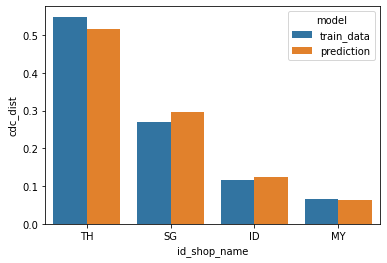

In [34]:
def get_cdc_distribution(input_data: pd.DataFrame, sales_column):
    
    total_sales = input_data[sales_column].sum()

    cdc_dist_data = input_data.groupby(['id_shop_name'])[sales_column].sum().reset_index()
    cdc_dist_data['cdc_dist'] = cdc_dist_data[sales_column] / total_sales

    return cdc_dist_data[['id_shop_name','cdc_dist']]

cdc_dist_test = get_cdc_distribution(mid_list, 'pred_round')
cdc_dist_test['model'] = 'prediction'

cdc_dist_train = get_cdc_distribution(mid_list, 'adjusted_net_units_sold')
cdc_dist_train['model'] = 'train_data'

cdc_dist = pd.concat([cdc_dist_test, cdc_dist_train])
cdc_dist.sort_values(by = 'cdc_dist', ascending = False, inplace = True)

display(cdc_dist.groupby(['id_shop_name', 'model'])[['cdc_dist']].mean())
sns.barplot(data = cdc_dist, x = 'id_shop_name', y = 'cdc_dist', hue = 'model')

In [35]:
''' Create time series plot '''
mj_agg = master_join.groupby(
    ['id_product', 'color', 'size', 'cluster', 'week_id', 'id_shop_name', 'date_released', 'release_collection_name']
).adjusted_net_units_sold.mean().reset_index()


mj_agg = pd.merge(
    mj_agg,
    data_test[['id_product', 'color', 'size', 'cluster', 'id_shop_name', 'week_id', 'date_released', 'release_collection_name', 'pred_round']],
    on = ['id_product', 'color', 'size', 'cluster', 'id_shop_name', 'date_released', 'week_id', 'release_collection_name'],
    how = 'left'
)

Text(0.5, 1.0, 'Test Set Evaluation; accuracy 82.74%')

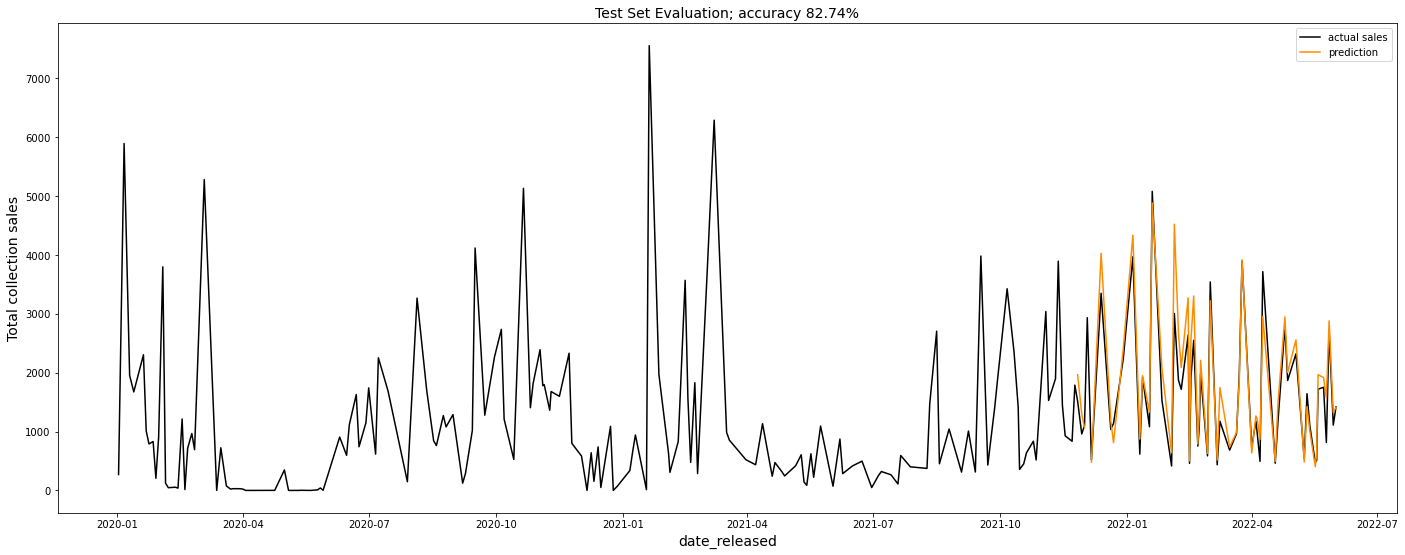

In [36]:
time_series = mj_agg.groupby(['release_collection_name', 'date_released'])[['pred_round','adjusted_net_units_sold']].sum().reset_index()
time_series = time_series.groupby('date_released')[['pred_round','adjusted_net_units_sold']].mean().reset_index()


time_series = time_series[time_series.date_released > pd.to_datetime('2019-12-30')]
time_series.pred_round.replace(0, np.nan, inplace = True)

tmp = time_series.dropna()
acc_ = np.round(accuracy(tmp.adjusted_net_units_sold, tmp.pred_round),2)

fig, ax = plt.subplots(figsize = (24,9))

#sns.set_style('whitegrid')

plt.plot(time_series.date_released, time_series.adjusted_net_units_sold, color = 'black', label = 'actual sales' )
plt.plot(time_series.date_released, time_series.pred_round, color = 'darkorange', label = 'prediction' )
#plt.xlim([0,10000])

plt.legend()

plt.xlabel('date_released', fontsize = 14)
plt.ylabel('Total collection sales', fontsize = 14)
plt.title(f'Test Set Evaluation; accuracy {acc_}%', fontsize = 14)

In [37]:
''' Check size distribution '''

def get_size_distribution(input_data, sales_column):
    #input_data = mid_list.copy()
    #sales_column = 'pred_round'

    size_vals = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL']
    input_data = input_data[input_data['size'].isin(size_vals)]

    total_size_dist = input_data.groupby(
        ['id_product','color', 'id_shop_name','sub_product_line', 'cluster']
    )[sales_column].sum().reset_index()
    total_size_dist.rename(columns = {sales_column: 'total_volume'}, inplace = True)

    size_dist_data = input_data.groupby(
        ['id_product','color', 'id_shop_name', 'cluster', 'sub_product_line','size']
    )[sales_column].sum().reset_index()
    size_dist_data.rename(columns = {sales_column: 'size_volume'}, inplace = True)

    size_dist_data = pd.merge(
        size_dist_data,
        total_size_dist,
        on = ['id_product','color', 'id_shop_name','sub_product_line', 'cluster'],
        how = 'left'
    )
    size_dist_data['size_dist'] = size_dist_data['size_volume'] / size_dist_data['total_volume']

    size_dist_data = size_dist_data.groupby(['id_shop_name', 'cluster', 'sub_product_line','size'])['size_dist'].mean().reset_index()

    size_dist_data['size'] = pd.Categorical(
        size_dist_data['size'], 
        categories=size_vals,
        ordered=True)

    size_dist_data.sort_values(by = 'size', inplace = True)
    size_dist_data['size'] = size_dist_data['size'].astype(str)
    
    return size_dist_data
    
    
size_dist_test = get_size_distribution(mid_list, 'pred_round')
size_dist_test['model'] = 'prediction'


size_dist_train = get_size_distribution(mid_list, 'adjusted_net_units_sold')
size_dist_train['model'] = 'Actual'

size_dist_data = pd.concat([size_dist_test, size_dist_train])


In [38]:
average_size_dist = size_dist_data.groupby(['id_shop_name','size','model']).size_dist.mean().reset_index()
average_size_dist['size_dist'] = np.round(average_size_dist['size_dist'] * 100,2)

size_vals = ['XXS', 'XS', 'S', 'M', 'L', 'XL', 'XXL']
average_size_dist['size'] = pd.Categorical(
        average_size_dist['size'], 
        categories=size_vals,
        ordered=True)

average_size_dist.sort_values(by = 'size', inplace = True)

ID shop name: MY
--------


,id_shop_name,size,model,size_dist
27,MY,XXS,prediction,26.48
26,MY,XXS,Actual,24.20
22,MY,XS,Actual,25.53
23,MY,XS,prediction,20.50
18,MY,S,Actual,24.97
19,MY,S,prediction,22.40
16,MY,M,Actual,17.19
17,MY,M,prediction,20.74
14,MY,L,Actual,13.18
15,MY,L,prediction,15.14


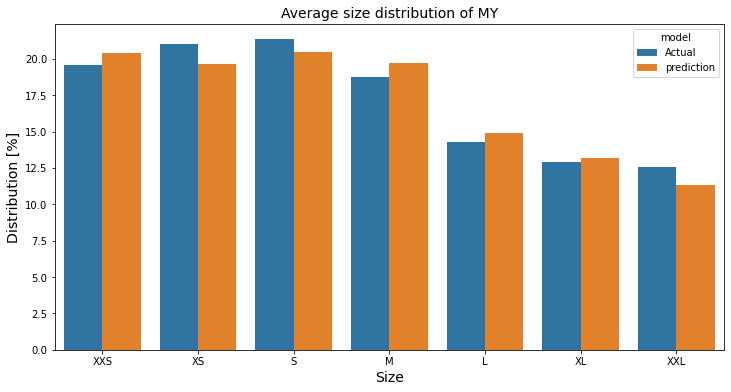

ID shop name: SG
--------


,id_shop_name,size,model,size_dist
41,SG,XXS,prediction,21.10
40,SG,XXS,Actual,20.25
37,SG,XS,prediction,20.24
36,SG,XS,Actual,23.46
32,SG,S,Actual,23.10
33,SG,S,prediction,21.53
30,SG,M,Actual,19.46
31,SG,M,prediction,20.65
29,SG,L,prediction,14.57
28,SG,L,Actual,12.96


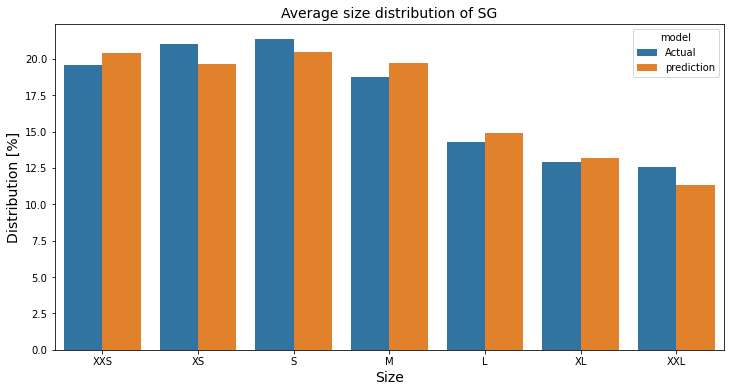

ID shop name: TH
--------


,id_shop_name,size,model,size_dist
54,TH,XXS,Actual,19.56
55,TH,XXS,prediction,20.43
51,TH,XS,prediction,19.66
50,TH,XS,Actual,21.05
47,TH,S,prediction,20.46
46,TH,S,Actual,21.35
45,TH,M,prediction,19.72
44,TH,M,Actual,18.74
43,TH,L,prediction,14.87
42,TH,L,Actual,14.29


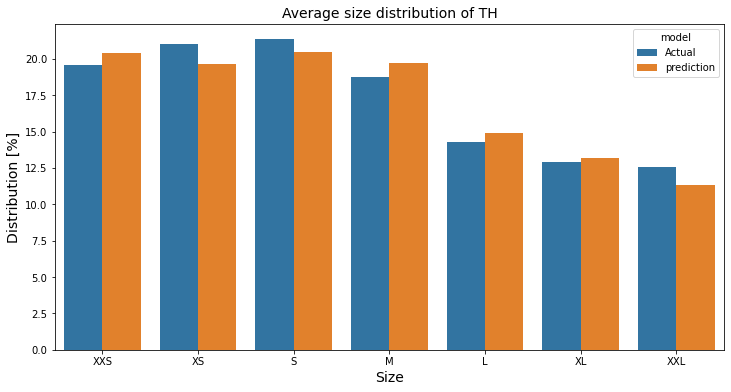

ID shop name: ID
--------


,id_shop_name,size,model,size_dist
13,ID,XXS,prediction,23.26
12,ID,XXS,Actual,18.15
8,ID,XS,Actual,17.60
9,ID,XS,prediction,18.79
5,ID,S,prediction,21.31
4,ID,S,Actual,25.04
2,ID,M,Actual,22.47
3,ID,M,prediction,20.56
1,ID,L,prediction,15.51
0,ID,L,Actual,13.79


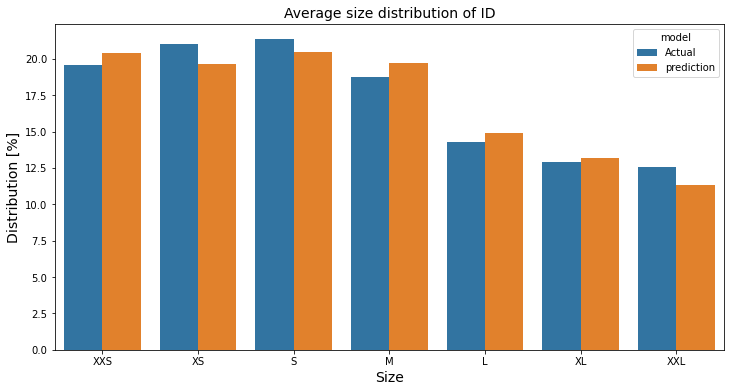

In [39]:
for wh in average_size_dist.id_shop_name.unique():
    print(f'ID shop name: {wh}')
    print('--------')
    tmp = average_size_dist[average_size_dist.id_shop_name == wh]
    display(tmp)
    
    fig, ax = plt.subplots(figsize = (12,6))
    tmp = average_size_dist[average_size_dist.id_shop_name == 'TH']
    sns.barplot(data = tmp, x = tmp['size'], y = tmp.size_dist, hue = 'model')

    plt.title(f'Average size distribution of {wh}', fontsize = 14)
    plt.xlabel('Size', fontsize = 14)
    plt.ylabel('Distribution [%]', fontsize = 14)
    plt.show()
    

In [40]:
FEATURES

Index(['product_cost_usd', 'original_price_usd', 'size', 'product_line', 'sub_product_line', 'henry_category_1', 'henry_category_2', 'henry_category_3', 'simple_color', 'color', 'fabric_custom_name', 'hscode_id_fabric_name', 'giveaway', 'cluster', 'pattern', 'sleevestyle', 'neckline', 'shape', 'rise', 'sleeve', 'style', 'week_id', 'id_shop_name', 'first_week_of_month', 'last_week_of_month', 'is_mega_campaign_order', 'avg_price_per_category', 'price_ratio_category', 'feature_price_cannibalization', 'feature_item_discount_mean', 'feature_item_discount_max', 'feature_item_discount_std', 'feature_voucher_discount_mean', 'feature_voucher_discount_max', 'feature_voucher_discount_std', 'feature_discount_utilization_mean', 'feature_discount_utilization_max', 'feature_discount_utilization_std', 'feature_traffic_dist_mean', 'feature_traffic_dist_max', 'feature_traffic_dist_std', 'feature_retail_mkt_spend_dist_mean', 'feature_retail_mkt_spend_dist_max', 'feature_retail_mkt_spend_dist_std', 'featu

In [ ]:
#shap.force_plot(explainer.expected_value, shap_values, X_pred)

# Model Deployment

In [45]:
# Offline Model Variables
OFFLINE_MODEL_RUN_DATE = '11082022'
MODEL_NAME_OFFLINE = 'offline_model_catboost'
LOCAL_OFFLINE_MODEL_SAVE_PATH = f'/home/ec2-user/SageMaker/ml-demand-forecasting/temp/model_saves/offline/{OFFLINE_MODEL_RUN_DATE}/model_offline_{OFFLINE_MODEL_RUN_DATE}'
S3_OFFLINE_MODEL_SAVE_PATH = f'data_science/dfm/offline_clothing_v2/{OFFLINE_MODEL_RUN_DATE}/model_offline_{OFFLINE_MODEL_RUN_DATE}'
S3_OFFLINE_DATA_FILE_PATH = f's3://hal-bi-bucket/data_science/dfm/offline_clothing_v2/{OFFLINE_MODEL_RUN_DATE}/master_join_offline.parquet'

FEATURES_OFFLINE = [
    'product_cost_usd',
    'original_price_usd',
    'size', 
    'product_line',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2', 
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'giveaway',
    'cluster',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'id_shop_name',
    'first_week_of_month',
    'last_week_of_month',
    'is_mega_campaign_order', 
    'avg_price_per_category',
    'price_ratio_category',
    'feature_price_cannibalization',
    'feature_item_discount_mean',
    'feature_item_discount_max',
    'feature_item_discount_std',
    'feature_voucher_discount_mean',
    'feature_voucher_discount_max',
    'feature_voucher_discount_std',
    'feature_discount_utilization_mean',
    'feature_discount_utilization_max',
    'feature_discount_utilization_std',
    'feature_traffic_dist_mean',
    'feature_traffic_dist_max',
    'feature_traffic_dist_std',
    'feature_retail_mkt_spend_dist_mean',
    'feature_retail_mkt_spend_dist_max',
    'feature_retail_mkt_spend_dist_std',
    'feature_sales_cat_mean',
    'feature_sales_cat_max',
    'feature_sales_cat_std',
    'feature_sales_cat2_mean',
    'feature_sales_cat2_max',
    'feature_sales_cat2_std',
    'feature_sales_cluster_mean',
    'feature_sales_cluster_max',
    'feature_sales_cluster_std',
    'feature_size_dist',
    'week_dist',
    'styles_in_collection'
]

CATEGORICAL_FEATURES_OFFLINE = [
    'size',
    'product_line',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'cluster',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'id_shop_name',
    'first_week_of_month',
    'last_week_of_month',
    'giveaway'
]


### Data preparation & model training

In [46]:
''' Read Data '''

READ_COLS =  FEATURES_OFFLINE + NO_TRAIN_COLS + ['adjusted_net_units_sold']

master_join = pd.read_parquet(S3_OFFLINE_DATA_FILE_PATH)
master_join.week_id = master_join.week_id.str.replace('week','').astype(int)
master_join['first_available_year'] = master_join['first_available_date'].dt.year
master_join = master_join[master_join.cluster != '-']
master_join = master_join[master_join.first_available_year > 2019]

In [47]:
feature_dist = get_feature_distribution(master_join)

In [49]:
#master_join_resampled = resample_to_cluster_level(master_join)
#master_join_resampled.to_csv('./master_join_resampled.csv')
master_join_resampled = pd.read_csv('./master_join_resampled.csv', index_col=0)

In [51]:
''' Create and add features  '''
master_join_resampled = add_price_features(master_join_resampled)

feature_sales_category, feature_sales_category2, feature_sales_cluster = get_historic_sales_statistics(master_join_resampled)

week_dist = get_historic_week_dist_feature(master_join_resampled)
week_dist.drop(columns = ["adjusted_net_units_sold", "total_sales"], axis = 1, inplace = True)

size_dist_features = get_size_distribution(master_join_resampled, 'adjusted_net_units_sold')
size_dist_features.rename(columns = {'size_dist': 'feature_size_dist'},inplace = True)


# Add discount, traffic and retail_dist features
master_join_resampled = pd.merge(
    master_join_resampled,
    feature_dist,
    on = ["id_shop_name",'sub_product_line','henry_category_2', "cluster", "week_id"],
    how = 'left'
)

# Sales by category
master_join_resampled = pd.merge(
    master_join_resampled,
    feature_sales_category,
    on = ['henry_category_2', 'size', 'color','week_id'],
    how = 'left'
)

# Sales by category2
master_join_resampled = pd.merge(
    master_join_resampled,
    feature_sales_category2,
    on = ['henry_category_2', 'size', 'color', 'cluster' ,'week_id'],
    how = 'left'
)

# Sales by cluster
master_join_resampled = pd.merge(
    master_join_resampled,
    feature_sales_cluster,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'size','week_id'],
    how = 'left'
)

# Size distribution
master_join_resampled = pd.merge(
    master_join_resampled,
    size_dist_features,
    on = ['id_shop_name', 'cluster', 'sub_product_line', 'size'],
    how = 'left'
)

# Week distribution
master_join_resampled = pd.merge(
    master_join_resampled,
    week_dist,
    on = ['henry_category_2', 'sub_product_line', 'cluster', 'id_shop_name', 'week_id'],
    how = 'left'
)

# Number of styles per collection feature
master_join_resampled['styles_in_collection'] = master_join_resampled.release_collection_name.map(
    dict(master_join_resampled.groupby('release_collection_name').id_product.nunique())
)

feature_cols = [col for col in master_join_resampled.columns if col.startswith('feature_')]


In [54]:
""" Undersample zero sales """
# Check that we did not miss any categories
n_cat1_before = master_join_resampled.henry_category_1.nunique()
n_cat2_before = master_join_resampled.henry_category_2.nunique()
n_cat3_before = master_join_resampled.henry_category_3.nunique()
n_cluster_before = master_join_resampled.cluster.nunique()
n_product_line_before = master_join_resampled.product_line.nunique()
n_spl_before = master_join_resampled.sub_product_line.nunique()
n_color_before = master_join_resampled.color.nunique()
n_simple_color_before = master_join_resampled.simple_color.nunique()
n_id_shop_before = master_join_resampled.id_shop_name.nunique()
n_size_before = master_join_resampled["size"].nunique()


new_idx = get_undersampling_index(master_join_resampled.adjusted_net_units_sold)
master_join_resampled = master_join_resampled[master_join_resampled.index.isin(new_idx)]
print(f'Proportion of zero sales in train data: {len(master_join_resampled[master_join_resampled.adjusted_net_units_sold == 0]) / len(master_join_resampled)}')


assert n_cat1_before == master_join_resampled.henry_category_1.nunique()
assert n_cat2_before == master_join_resampled.henry_category_2.nunique()
assert n_cat3_before == master_join_resampled.henry_category_3.nunique()
assert n_cluster_before == master_join_resampled.cluster.nunique()
assert n_product_line_before == master_join_resampled.product_line.nunique()
assert n_spl_before == master_join_resampled.sub_product_line.nunique()
assert n_color_before == master_join_resampled.color.nunique()
assert n_simple_color_before == master_join_resampled.simple_color.nunique()
assert n_id_shop_before == master_join_resampled.id_shop_name.nunique()
assert n_size_before == master_join_resampled["size"].nunique()

Proportion of zero sales in train data: 0.5


In [56]:
master_join_resampled.shape

(749860, 64)

In [58]:
no_train_cols = [
    'id_product', 'id_product_attribute', 'release_collection_name' ,'date_released',
    'first_available_dow','first_available_month', 'first_available_year'
]

X = master_join_resampled[FEATURES_OFFLINE]
Y = master_join_resampled["adjusted_net_units_sold"]


cat_idx = [key for key, val in enumerate(FEATURES_OFFLINE) if val in set(CATEGORICAL_FEATURES_OFFLINE)]

for col in CATEGORICAL_FEATURES_OFFLINE:
    X[col].fillna('others', inplace = True)
    
for feat in feature_cols:
    X[feat].fillna(np.mean(X[feat]), inplace = True)
    
# fill na in week_dist
week_dist_fillna = week_dist.groupby("week_id").week_dist.mean()
for week_ in X.week_id.unique():
    X.loc[(X.week_id == week_) & (X.week_dist.isna()), "week_dist"] = week_dist_fillna[week_]
    
# train/val split

split_ratio = 0.2
x_train, x_val, y_train, y_val = train_test_split(
    X, Y, test_size=split_ratio, random_state=0
)
del X,Y

In [59]:
clf = CatBoostRegressor(
    depth=8,
    l2_leaf_reg=1.5,
    learning_rate=0.3,
    loss_function='RMSE'
)

clf.fit(x_train.values, y_train.values, 
        cat_features=cat_idx,
        eval_set=(x_val.values, y_val.values),
        early_stopping_rounds = 5,
        use_best_model = True,
        verbose=True,
        plot = True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7378181	test: 0.7325039	best: 0.7325039 (0)	total: 468ms	remaining: 7m 47s
1:	learn: 0.7040278	test: 0.7015757	best: 0.7015757 (1)	total: 976ms	remaining: 8m 6s
2:	learn: 0.6841480	test: 0.6832405	best: 0.6832405 (2)	total: 1.39s	remaining: 7m 43s
3:	learn: 0.6703699	test: 0.6710367	best: 0.6710367 (3)	total: 1.86s	remaining: 7m 43s
4:	learn: 0.6625225	test: 0.6636160	best: 0.6636160 (4)	total: 2.32s	remaining: 7m 40s
5:	learn: 0.6566997	test: 0.6585683	best: 0.6585683 (5)	total: 2.67s	remaining: 7m 23s
6:	learn: 0.6518170	test: 0.6541449	best: 0.6541449 (6)	total: 3.15s	remaining: 7m 26s
7:	learn: 0.6475328	test: 0.6500811	best: 0.6500811 (7)	total: 3.6s	remaining: 7m 25s
8:	learn: 0.6450120	test: 0.6482478	best: 0.6482478 (8)	total: 4.01s	remaining: 7m 21s
9:	learn: 0.6426117	test: 0.6464326	best: 0.6464326 (9)	total: 4.41s	remaining: 7m 16s
10:	learn: 0.6394213	test: 0.6440753	best: 0.6440753 (10)	total: 4.77s	remaining: 7m 8s
11:	learn: 0.6375321	test: 0.6422292	best: 0

### Upload model & results to S3

In [63]:
report_model_performance('final catboost model', y_val, clf.predict(x_val))

Percentage error of final catboost model: 73.0%
Bias of final catboost model: 0.0
Mean absolute error of final catboost model: 0.35
Average actual sales: 0.48
Average prediction: 0.49


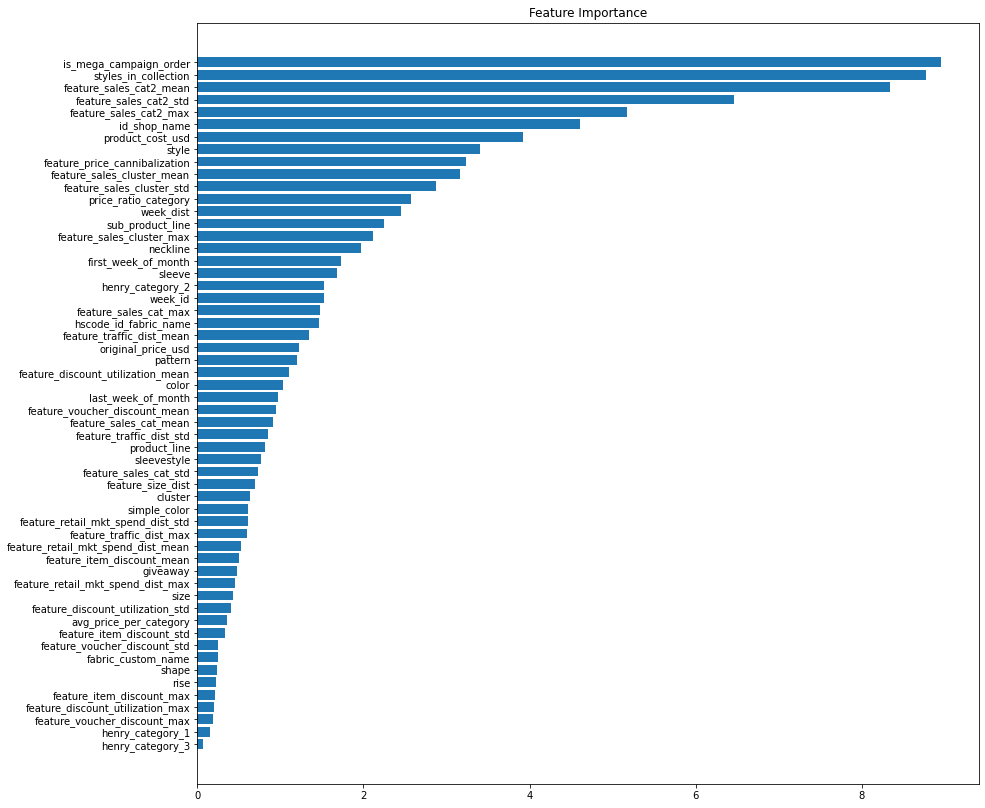

In [83]:
feature_importance = clf.feature_importances_
sorted_idx = np.argsort(feature_importance)
fig = plt.figure(figsize=(14, 14))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(x_val.columns)[sorted_idx])
plt.title('Feature Importance')
plt.savefig(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/feature_importance_cat.png')
plt.show()

upload_file_to_s3(
    f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/feature_importance_cat.png',
    f'{S3_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}_feature_importance.png',
    S3_BUCKET
)

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


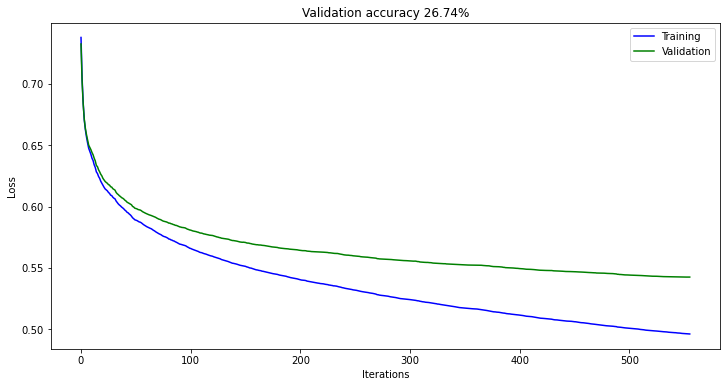

In [82]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (12,6))

acc_ = np.round(accuracy(y_val, clf.predict(x_val)),2)

train_rmse = clf.evals_result_['learn']['RMSE']
val_rmse = clf.evals_result_['validation']['RMSE']
plt.plot(np.arange(0,len(train_rmse)), train_rmse, color = 'blue', label = 'Training')
plt.plot(np.arange(0,len(train_rmse)), val_rmse, color = 'green' ,label = 'Validation')
plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title(f'Validation accuracy {acc_}%')

plt.savefig(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}_train_loss.png')

upload_file_to_s3(
    f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}_train_loss.png',
    f'{S3_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}_train_loss.png',
    S3_BUCKET
)

In [84]:
clf.save_model(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}')

In [90]:
upload_file_to_s3(
    f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}',
    f'{S3_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}',
    S3_BUCKET
)


/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/boto3/compat.py:88: PythonDeprecationWarning: Boto3 will no longer support Python 3.6 starting May 30, 2022. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.7 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


In [87]:
''' Test load / download 
download_file_from_s3(
    f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}',
    f'{S3_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}',
    S3_BUCKET
)


from_file = CatBoostRegressor()
model = from_file.load_model(f'{LOCAL_OFFLINE_MODEL_SAVE_PATH}/{MODEL_NAME_OFFLINE}_new')

report_model_performance('final catboost model', y_val, model.predict(x_val))
'''


### Set new variables to put in config/model_config.py

In [88]:
# Offline Model Variables
OFFLINE_MODEL_RUN_DATE = '11082022'
MODEL_NAME_OFFLINE = 'offline_model_catboost'
LOCAL_OFFLINE_MODEL_SAVE_PATH = '/home/ec2-user/SageMaker/ml-demand-forecasting/temp/model_saves/offline/11082022/model_offline_11082022/offline_model_catboost'
S3_OFFLINE_MODEL_SAVE_PATH = 's3://hal-bi-bucket/data_science/dfm/offline_clothing_v2/11082022/model_offline_11082022/offline_model_catboost'
S3_OFFLINE_DATA_FILE_PATH = f's3://hal-bi-bucket/data_science/dfm/offline_clothing_v2/{OFFLINE_MODEL_RUN_DATE}/master_join_offline.parquet'

FEATURES_OFFLINE = [
    'product_cost_usd',
    'original_price_usd',
    'size', 
    'product_line',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2', 
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'giveaway',
    'cluster',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'id_shop_name',
    'first_week_of_month',
    'last_week_of_month',
    'is_mega_campaign_order', 
    'avg_price_per_category',
    'price_ratio_category',
    'feature_price_cannibalization',
    'feature_item_discount_mean',
    'feature_item_discount_max',
    'feature_item_discount_std',
    'feature_voucher_discount_mean',
    'feature_voucher_discount_max',
    'feature_voucher_discount_std',
    'feature_discount_utilization_mean',
    'feature_discount_utilization_max',
    'feature_discount_utilization_std',
    'feature_traffic_dist_mean',
    'feature_traffic_dist_max',
    'feature_traffic_dist_std',
    'feature_retail_mkt_spend_dist_mean',
    'feature_retail_mkt_spend_dist_max',
    'feature_retail_mkt_spend_dist_std',
    'feature_sales_cat_mean',
    'feature_sales_cat_max',
    'feature_sales_cat_std',
    'feature_sales_cat2_mean',
    'feature_sales_cat2_max',
    'feature_sales_cat2_std',
    'feature_sales_cluster_mean',
    'feature_sales_cluster_max',
    'feature_sales_cluster_std',
    'feature_size_dist',
    'week_dist',
    'styles_in_collection'
]

CATEGORICAL_FEATURES_OFFLINE = [
    'size',
    'product_line',
    'sub_product_line',
    'henry_category_1',
    'henry_category_2',
    'henry_category_3',
    'simple_color',
    'color',
    'fabric_custom_name',
    'hscode_id_fabric_name',
    'is_mega_campaign_order',
    'cluster',
    'pattern',
    'sleevestyle',
    'neckline',
    'shape',
    'rise',
    'sleeve',
    'style', 
    'week_id',
    'id_shop_name',
    'first_week_of_month',
    'last_week_of_month',
    'giveaway'
]


Percentage error of final catboost model: 73.0%
Bias of final catboost model: 0.0
Mean absolute error of final catboost model: 0.35
Average actual sales: 0.48
Average prediction: 0.49


In [ ]:
''' Saving model '''




In [210]:
master_join_resampled.first_available_year 

0          2020
1          2020
4          2020
7          2020
17         2020
           ... 
1333488    2022
1333489    2022
1333490    2022
1333491    2022
1333493    2022
Name: first_available_year, Length: 749860, dtype: int64

# Backup campaign features

In [241]:
''' Create campaign features from scratch '''
# dates for megacampaing in format MM-DD

campaign_dates = [
    '03-25', # pomelo birthday
    '04-04',
    '05-05',
    '06-06',
    '07-07',
    '08-08',
    '09-09',
    '10-10',
    '11-11',
    '11-24', # black friday
    '12-12'
]

tmp = master_join_resampled[master_join_resampled.first_available_year > 2019].copy()
year_range = [2016, 2017, 2018, 2019, 2020, 2021, 2022]

tmp['week_id_minus1'] = tmp['week_id'] - 1
tmp["start_date_weekly"] = pd.DatetimeIndex(tmp["date_released"]) + tmp["week_id_minus1"].apply(pd.offsets.Week)
tmp.drop(columns = 'week_id_minus1', axis = 1, inplace = True)

# Check the week, i.e. +/- 3 days
tmp['start_date_weekly_start_date'] = tmp["start_date_weekly"] - timedelta(days=3)
tmp['start_date_weekly_end_date'] = tmp["start_date_weekly"] + timedelta(days=3)

#tmp['start_date_weekly_start_date'] = tmp["start_date_weekly"] - timedelta(days=tmp["start_date_weekly"].dt.weekday)
#tmp['start_date_weekly_end_date'] = tmp["start_date_weekly_start_date"] + timedelta(days=6)

is_campaign_date_list = list()
for y in year_range:
    for date_ in campaign_dates:
        is_campaign_date_list.append(
            pd.to_datetime( str(y) + '-' + date_, format = "%Y-%m-%d")
        )
        
for date_ in is_campaign_date_list:
    tmp.loc[(tmp.start_date_weekly_start_date < date_) & (date_ < tmp.start_date_weekly_end_date), 'is_mega_campaign_test'] = 1
    
tmp.is_mega_campaign_test.fillna(0, inplace = True)

/home/ec2-user/anaconda3/envs/amazonei_tensorflow2_p36/lib/python3.6/site-packages/pandas/core/arrays/datetimelike.py:1345: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized
  PerformanceWarning,


In [197]:
tmp[['is_mega_campaign', 'is_mega_campaign_test']]

,is_mega_campaign_order,is_mega_campaign_test
0,0,0.0
1,0,0.0
4,0,1.0
7,0,0.0
17,0,0.0
...,...,...
1333488,0,0.0
1333489,0,1.0
1333490,0,0.0
1333491,0,0.0


In [168]:
year_range

for y in year_range:
    print(y)

2016
2017
2018
2019
2020
2021
2022
2023
2024


In [143]:
test_date = is_mega_campaign_list[0]
test_date_day = test_date.split('-')[0]
test_date_month = test_date.split('-')[1]


start_date = tmp.start_date_weekly.iloc[-1]
campaign_date = pd.to_datetime(test_date + '-' + start_date.year)


TypeError: must be str, not int

In [146]:
test_date + '-' + start_date.year.asytype(str)

AttributeError: 'int' object has no attribute 'asytype'

In [142]:
pd.to_datetime([1,1,2022])

DatetimeIndex(['1970-01-01 00:00:00.000000001', '1970-01-01 00:00:00.000000001', '1970-01-01 00:00:00.000002022'], dtype='datetime64[ns]', freq=None)

In [132]:
test_date.split('-')[1]

'03'

In [ ]:
tmp.loc[  , 'is_mega_campaign_date']

In [118]:
tmp[['start_date_weekly_start_date', 'start_date_weekly', 'start_date_weekly_end_date']]

,start_date_weekly_start_date,start_date_weekly,start_date_weekly_end_date
0,2017-03-04,2017-03-07,2017-03-10
1,2017-03-11,2017-03-14,2017-03-17
4,2017-04-01,2017-04-04,2017-04-07
7,2017-12-16,2017-12-19,2017-12-22
17,2018-01-06,2018-01-09,2018-01-12
...,...,...,...
1333488,2022-05-27,2022-05-30,2022-06-02
1333489,2022-06-03,2022-06-06,2022-06-09
1333490,2022-06-10,2022-06-13,2022-06-16
1333491,2022-06-17,2022-06-20,2022-06-23


In [103]:
from datetime import timedelta

In [105]:
cutoff_date = tmp["date_released"] - timedelta(days=3)

0         2017-03-04
1         2017-03-04
4         2017-03-04
7         2017-12-16
17        2017-12-16
             ...    
1333488   2022-05-27
1333489   2022-05-27
1333490   2022-05-27
1333491   2022-05-27
1333493   2022-05-27
Name: date_released, Length: 749860, dtype: datetime64[ns]

In [ ]:
tmp['start_date_weekly_start_date'] = pd.DatetimeIndex(tmp["start_date_weekly"]) + tmp["week_id_minus1"].apply(pd.offsets.Week)

# Backup time seires bases features 

In [ ]:



["id_shop_name",'sub_product_line','henry_category_1', "cluster", "week_id"]


def add_similariy_ids(input_df: pd.DataFrame) -> pd.DataFrame:
    ''' Adds some helper id columns for to calculate similarities '''
    
    input_df.loc[:,'similarity_1'] = (
        input_df['id_shop_name'].astype(str) + '-' + 
        input_df['sub_product_line'].astype(str) + '-' + 
        input_df['henry_category_1'].astype(str) + '-' + 
        input_df['cluster'].astype(str) + '-' + 
        input_df['week_id'].astype(str)
    )
    

    return input_df

def _get_last_possible_date(date_list, date):
    """ checks date_list for the largest entry that is smaller than date """
    tmp = date_list[date_list < date]
    if len(tmp) > 0:
        return max(tmp)
    else:
        return np.nan
    
def get_valid_date(mj: pd.DataFrame, lookback_weeks) -> pd.DataFrame:
    """ Adds a date columm that specifies the last valid date to be used as features. 
    This will be the latest date in the dataframe that is at least 17 week apart from date_released.
    """
    # factor 2 since we forecast date_released 17 weeks into the future, for different weeks
    td = pd.Timedelta(2 * lookback_weeks , "w")
    mj['past_date'] = mj.first_available_date - td
    
    unique_dates = mj.date_released.unique()
    dates = dict(zip(mj.date_released.unique(),mj.past_date.unique()))
    
    date_dict = dict()
    for today, past in dates.items():
        date_dict[today] = _get_last_possible_date(unique_dates, past)
        
    
    mj['valid_date'] = mj.past_date.map(date_dict)
    mj.drop(columns = ['past_date'], inplace = True)
    
    return mj

def get_time_series_mean(df: pd.DataFrame, agg_col: list ,similariy_cols: list) -> pd.DataFrame :
    ''' Gets a time series averageing over all similarity_idx and released dates.
    Ex: If similariy is dresses-xxs then all sales of dresses-xxs with the same release_date get averaged
    Make sure df is sorted already based on date_released.
    ''' 
    result = df.groupby(['date_released'] + similariy_cols)[agg_col].mean().reset_index()
    result.set_index('date_released', inplace = True)
    return result
    
    
def get_rolling_features(ts_df: pd.DataFrame, agg_col: list, similariy_cols: list ,rolling_window_list: list, agg_func: str)-> pd.DataFrame:
    """ Returns rolling features specified in rolling_window list for agg_function """
    
    for window in rolling_window_list:
        agg_col_str = agg_col[0] # we pass it as a list
        sim_col_str = similariy_cols[0]
        feature_name = f'feat_{sim_col_str}_{agg_func}_{agg_col_str}_w{window}'
        ts_df.loc[:,feature_name] = ts_df.groupby(similariy_cols)[agg_col].rolling(window).agg(agg_func)[agg_col].values
        
        # back fill and front fill NA due to window extesions
        ts_df[feature_name] = ts_df.groupby(similariy_cols)[[feature_name]].bfill().ffill()
    
    ts_df.drop(columns = agg_col, inplace = True)
    ts_df.reset_index(inplace = True)
    return ts_df